# Module 3 - push notifications: predictive model

**Goal**: Given a user and a product, predict whether the user would purchase it in their current basket.
Only orders with ≥5 items purchased.

## Milestone 1 - Exploration & model selection

### 1. Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)

In [2]:
DATA_PATH = "../data/module_2/box_builder_dataset/feature_frame.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["order_date", "created_at"])
print(df.shape)
df.head(3)

(2880549, 27)


,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


### 2. Filter: orders with ≥5 items purchased

Each row is a (order, product) pair. The filter applies to products actually bought (`outcome == 1`) per order - all orders already expose the full product catalogue (~836 rows each).

In [3]:
items_bought_per_order = df[df["outcome"] == 1.0].groupby("order_id")["variant_id"].count()
print("Items purchased per order:")
print(items_bought_per_order.describe())
print(f"\nOrders with <5 items purchased: {(items_bought_per_order < 5).sum()} / {len(items_bought_per_order)}")

Items purchased per order:
count    3427.000000
mean        9.697111
std         6.789204
min         1.000000
25%         5.000000
50%         9.000000
75%        13.000000
max        78.000000
Name: variant_id, dtype: float64

Orders with <5 items purchased: 824 / 3427


In [4]:
valid_orders = items_bought_per_order[items_bought_per_order >= 5].index
df = df[df["order_id"].isin(valid_orders)].reset_index(drop=True)
print(f"Dataset after filter: {df.shape}")
print(f"\nClass balance:\n{df['outcome'].value_counts()}")
print(f"\nPositive rate: {df['outcome'].mean():.4f}")

Dataset after filter: (2163953, 27)

Class balance:
outcome
0.0    2132624
1.0      31329
Name: count, dtype: int64

Positive rate: 0.0145


### 3. Feature selection

The dataset contains 27 columns:

EXCLUDE:
- variant_id, order_id, user_id are IDs, so if the model learns from them, it memorizes instead of generalize.
- outcome is the target, it cannot be a feature
- order_date, created_at are used for the split, but they are not raw features to be used
- vendor: it has 264 columns which would ned OHE, but that's a lot of noise

INCLUDE:
- product_type: One-Hot Encoding
- The rest, they don't need any transformation to be used in logistic regression


In [5]:
print(f"product_type: {df['product_type'].nunique()} categories")
print(f"vendor:       {df['vendor'].nunique()} categories")
print(f"user_order_seq range: {df['user_order_seq'].min()} – {df['user_order_seq'].max()}")

product_type: 62 categories
vendor:       264 categories
user_order_seq range: 2 – 21


In [ ]:
df = pd.get_dummies(df, columns=["product_type"], drop_first=True)

NUMERIC_COLS = [
    "ordered_before", "abandoned_before", "active_snoozed", "set_as_regular",
    "normalised_price", "discount_pct", "global_popularity",
    "count_adults", "count_children", "count_babies", "count_pets", "people_ex_baby",
    "days_since_purchase_variant_id", "avg_days_to_buy_variant_id", "std_days_to_buy_variant_id",
    "days_since_purchase_product_type", "avg_days_to_buy_product_type", "std_days_to_buy_product_type",
    "user_order_seq",
]
PT_COLS = [c for c in df.columns if c.startswith("product_type_")]
FEATURE_COLS = NUMERIC_COLS + PT_COLS
TARGET = "outcome"

print(f"Total features: {len(FEATURE_COLS)} ({len(NUMERIC_COLS)} numeric + {len(PT_COLS)} product_type )")

Total features: 80 (19 numeric + 61 product_type dummies)


### 4. Train / validation / test split

The same user appears in multiple orders in time, so if we do a random split, we could be training with the future and evaluating with the past, so we use a **temporal split** on order date.
We order all the oerders by date and cut: 60% train / 20% validation / 20% test

In [7]:
orders_by_date = (
    df[["order_id", "order_date"]]
    .drop_duplicates()
    .sort_values("order_date")
    .reset_index(drop=True)
)
n = len(orders_by_date)
cutoff_val  = orders_by_date.iloc[int(n * 0.6)]["order_date"]
cutoff_test = orders_by_date.iloc[int(n * 0.8)]["order_date"]

train_mask = df["order_date"] < cutoff_val
val_mask   = (df["order_date"] >= cutoff_val) & (df["order_date"] < cutoff_test)
test_mask  = df["order_date"] >= cutoff_test

X_train, y_train = df.loc[train_mask, FEATURE_COLS], df.loc[train_mask, TARGET]
X_val,   y_val   = df.loc[val_mask,   FEATURE_COLS], df.loc[val_mask,   TARGET]
X_test,  y_test  = df.loc[test_mask,  FEATURE_COLS], df.loc[test_mask,  TARGET]

print(f"Train:      < {cutoff_val.date()}   {len(y_train):>8,} rows  pos rate: {y_train.mean():.4f}")
print(f"Validation: < {cutoff_test.date()}  {len(y_val):>8,} rows  pos rate: {y_val.mean():.4f}")
print(f"Test:       >= {cutoff_test.date()}  {len(y_test):>8,} rows  pos rate: {y_test.mean():.4f}")

Train:      < 2021-01-26   1,207,702 rows  pos rate: 0.0153
Validation: < 2021-02-15   453,596 rows  pos rate: 0.0136
Test:       >= 2021-02-15   502,655 rows  pos rate: 0.0132


### 5. Model training and regularisation 

We train logistic regression with both L1 (Lasso) and L2 (Ridge), sweeping `C` (inverse regularisation: very low C means a lot of regularisation; and big C means low regularisation) across several orders. This until we find the optimal C between both extrems.

**Metric**: PR-AUC. Accuracy is meaningless at 98.5% negatives. ROC-AUC can be misleading under heavy imbalance. PR-AUC focuses on the positive class.

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10]
sweep_results = []

for C in C_values:
    m = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=1000, class_weight="balanced", random_state=42)
    m.fit(X_train_s, y_train)
    ap_tr = average_precision_score(y_train, m.predict_proba(X_train_s)[:, 1])
    ap_va = average_precision_score(y_val,   m.predict_proba(X_val_s)[:, 1])
    sweep_results.append({"penalty": "L2", "C": C, "train_AP": ap_tr, "val_AP": ap_va, "model": m})

m_l1 = LogisticRegression(penalty="l1", C=0.1, solver="liblinear", max_iter=1000, class_weight="balanced", random_state=42)
m_l1.fit(X_train_s, y_train)
sweep_results.append({
    "penalty": "L1", "C": 0.1,
    "train_AP": average_precision_score(y_train, m_l1.predict_proba(X_train_s)[:, 1]),
    "val_AP":   average_precision_score(y_val,   m_l1.predict_proba(X_val_s)[:, 1]),
    "nonzero":  int((m_l1.coef_[0] != 0).sum()),
    "model": m_l1,
})

sweep_df = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in sweep_results])
sweep_df["gap"] = sweep_df["train_AP"] - sweep_df["val_AP"]
print(sweep_df.to_string(index=False))

penalty      C  train_AP   val_AP  nonzero       gap
     L2  0.001  0.138186 0.143297      NaN -0.005111
     L2  0.010  0.138194 0.143409      NaN -0.005215
     L2  0.100  0.138251 0.143408      NaN -0.005157
     L2  1.000  0.138218 0.143409      NaN -0.005191
     L2 10.000  0.138215 0.143409      NaN -0.005194
     L1  0.100  0.138201 0.143296     74.0 -0.005095


val_AP is practically identical for C=0.001 and C=0.1. This implies high bias, the model reached its capacity with these features, it cannot learn more.
L1 and L2 give exact the same. L1 eliminates 6 features (from 80 to 74), but the val_AP is the same that in L2. This means that 6 features didn't add any value.
The gap is negative (train_AP < val_AP), which is rare because usually the model works better in train that in val. 

Maybe to improve we could add new features (interactions between features), or use a non-linear model such as a decision tree.

### 6. Bias-variance analysis

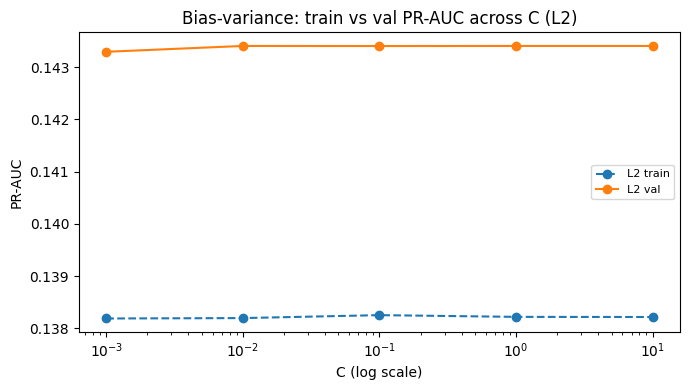

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sub = sweep_df[sweep_df["penalty"] == "L2"]
ax.plot(sub["C"], sub["train_AP"], linestyle="--", marker="o", label="L2 train")
ax.plot(sub["C"], sub["val_AP"],   linestyle="-",  marker="o", label="L2 val")
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("PR-AUC")
ax.set_title("Bias-variance: train vs val PR-AUC across C (L2)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

As we saw before, val_AP does not increase or decrease when C changes, which means high bias.
The conclusion we get is that the problem is not having too many features (for which we would use L1), or that we need more or less regularisation changing C. The prpblem is that the features we have, don't show enough information.

### 7. Final model selection and test evaluation

**Selected model**: Logistic Regression L2 balanced, C=0.1.
Because:
- L2 and L1 give identical val PR-AUC, so as L2 is simpler and more stable under this high-bias, we choose L2.
- `class_weight='balanced'` produces better-calibrated probabilities scores across the range, not just "no buy" always in any case.
- C=0.1 adds a bit stronger regularisation compared to C=1 and C=10,  at no cost to performance
Test set is evaluated **once only**.

In [11]:
best_model = next(r["model"] for r in sweep_results if r["penalty"] == "L2" and r["C"] == 0.1)
proba_val  = best_model.predict_proba(X_val_s)[:, 1]
proba_test = best_model.predict_proba(X_test_s)[:, 1]

print("Final model: LR L2 balanced, C=0.1")
print(f"  Val  PR-AUC:  {average_precision_score(y_val,  proba_val):.4f}")
print(f"  Test PR-AUC:  {average_precision_score(y_test, proba_test):.4f}")
print(f"  Val  ROC-AUC: {roc_auc_score(y_val,  proba_val):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}")

Final model: LR L2 balanced, C=0.1
  Val  PR-AUC:  0.1434


  Test PR-AUC:  0.1525
  Val  ROC-AUC: 0.8375


  Test ROC-AUC: 0.8320


Val and test are really close, so the model generalises well to unseen data.

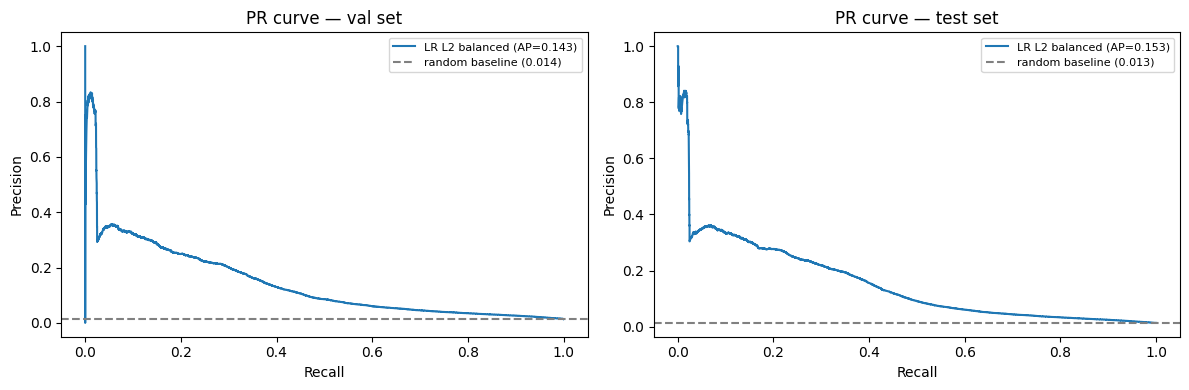

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (proba, y, split) in zip(axes, [(proba_val, y_val, "val"), (proba_test, y_test, "test")]):
    precision, recall, _ = precision_recall_curve(y, proba)
    ap = average_precision_score(y, proba)
    ax.plot(recall, precision, label=f"LR L2 balanced (AP={ap:.3f})")
    ax.axhline(y.mean(), color="gray", linestyle="--", label=f"random baseline ({y.mean():.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"PR curve — {split} set")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
coef_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "coef": best_model.coef_[0]})
    .assign(abs_coef=lambda x: x["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
print("Top 15 features by absolute coefficient:")
print(coef_df.head(15).to_string(index=False))

Top 15 features by absolute coefficient:
                             feature      coef
                   global_popularity  0.730972
                      ordered_before  0.410629
                product_type_nappies -0.284813
       product_type_babyfood12months -0.226857
        product_type_babymilkformula -0.217105
        std_days_to_buy_product_type -0.194813
        product_type_babyfood6months -0.193196
product_type_longlifemilksubstitutes -0.177602
                    abandoned_before  0.170787
              product_type_maternity -0.150418
             product_type_kidssnacks -0.130318
 product_type_cookingingredientsoils  0.122446
    product_type_dishwasherdetergent  0.118600
          product_type_bathshowergel  0.116257
             product_type_nappypants -0.115740


### 8. Conclusions: what worked and what not

**What worked**:
- The model correctly identifies the most important signals: `global_popularity` and `ordered_before`. This makes sense: if a product is really popular globally, there's more probability that someone buys it; and if that user has already bought that product before, the probability is even higher.
- PR-AUC ~0.14 on val and ~0.15 on test (above random chance (~0.014)). Consistent performance in val and test can confirm the model generalises across this time window.
- Temporal split correctly prevents information leakage from future user behaviour. If we would have made a random split, the model could have learnt "patrones" from a user, seeing its future orders in training phase.
- `product_type` and `user_order_seq` add small but real improvement over numeric-only features. Without them, the model had only 19 numeric features, but with `product_type` (61 extra cols) and  `user_order_seq`, the model has a bit more of context about the type of product and in what point of the history of orders is the user found.

**What did not work /limitations**:
- **C has no effect**: val PR-AUC is flat from C=0.001 to C=10. This is high bias: the model has so few to learn from features on its actual form, that more or less regularisation doen't change anything.The problem is not over or underfitting by excess of parameters, is that the representation of data is not enough for a linear model.
- **L1 vs L2 is irrelevant**: both converge to the same val PR-AUC. L1 eliminates some coefficients from product_type that are marginal, but the final result is the same. Maybe because the same explanation as before, the regilarisation at that point is irrelevant.
- **PR-AUC of ~0.14 is modest**: at recall=0.5 (capturing half of the real users), precision is around 10–15%. This means that, for every notification we send, only 1 from every 7-10 users will buy. If the cost of sending a notification is low, it can maybe be acceptable, but if the user gets bothered and stops opening notifications, this can be a problem.
- **Main cause of the ceiling**: many features have very low variance (for example `days_since_purchase_variant_id` has the same value (~33) for the vast majority of rows because it's a fill value for products never purchased). The truly discriminative features are `global_popularity`, `ordered_before`, `normalised_price`, and a few product_type dummies.
- **To improve from this point within linear models**: the next point would be creating feature interactions (for ex. `ordered_before × global_popularity`, `normalised_price × product_type`). Outside of linear models, tree methods would capture these non-linearities directly, without needing to create the interactions by hand.